In [1]:
from pathlib import Path
import sys

# Make sibling package imports work regardless of notebook launch directory.
project_root = Path.cwd()
if not (project_root / "ML_pipeline").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ML_pipeline.data_preprocessing import HeartbeatDataProcessor


In [2]:
folder_path='../data/PAMAP2_Dataset/Protocol/'
filtered_df_path='../ML_pipeline/'
processed_data = HeartbeatDataProcessor(
    folder_path,
    filtered_df_path,
    include_amplitude=False,
    include_frequency=True,
    reduced_frequency=True
)
processed_data.preprocess_subjects(range(101,109))
# print(processed_data.df_filtered.head(3))
# print(processed_data.filtered_index.head(3))


Selected DataFrame columns have 0.3868% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0% NaNs!

Adjusted low-pass cutoff from 16.0Hz to 4.275Hz for sample_rate=9Hz.
Skipping 18 missing motion axes in filtering (likely dropped by preprocessing mode).
successfully loaded subject 101
Selected DataFrame columns have 0.5957% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0% NaNs!

Adjusted low-pass cutoff from 16.0Hz to 4.275Hz for sample_rate=9Hz.
Skipping 18 missing motion axes in filtering (likely dropped by preprocessing mode).
successfully loaded subject 102
Selected DataFrame columns have 0.2078% NaNs.
Interpolating selected columns...
Selected DataFrame columns now have 0.0% NaNs!

Adjusted low-pass cutoff from 16.0Hz to 4.275Hz for sample_rate=9Hz.
Skipping 18 missing motion axes in filtering (likely dropped by preprocessing mode).
successfully loaded subject 103
Selected DataFrame columns have 0.7006% NaNs.
Interpolatin

In [3]:
print(processed_data.df_filtered.head(3))


   timestamp  activity_id  heart_rate  hand_temp  hand_acc16_x  hand_acc16_y  \
0      72.06            1        84.0    33.8125     -9.583883     -1.443686   
1      72.17            1        84.0    33.8125     -9.469050     -1.492708   
2      72.28            1        84.0    33.8125     -9.531168     -1.129986   

   hand_acc16_z  hand_gyro_x  hand_gyro_y  hand_gyro_z  hand_mag_x  \
0      0.355085    -0.043194    -0.003252     0.013285   48.027267   
1      0.343163    -0.033896     0.013097     0.006544   47.886028   
2      0.001536    -0.156010     0.016840     0.034356   48.037183   

   hand_mag_y  hand_mag_z  subject_id  interval_id  
0   -6.389573   14.308159         108           91  
1   -6.533140   14.404855         108           91  
2   -6.632410   14.290853         108           91  


## Random Forest on subject segments

This notebook uses only time-domain and FFT-domain features (no amplitude-domain features).


In [4]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

slices = []
for i in range(101, 109):
    slices.extend([s for s in processed_data.subject_segment_dict[i] if not s.empty])

feature_rows = []
labels = []
groups = []

for slice_df in slices:
    if slice_df.empty:
        continue

    label = int(slice_df["activity_id"].mode().iloc[0])
    row = processed_data.extract_random_forest_features(slice_df).to_dict()

    feature_rows.append(row)
    labels.append(label)
    groups.append(int(slice_df["interval_id"].iloc[0]))

X = pd.DataFrame(feature_rows)
y = pd.Series(labels, name="activity_id")




groups = pd.Series(groups, name="interval_id")


In [5]:
display(X.head(3))
display(y.head(3))
display(groups.head(3))
# Combine activity labels into broader classes.
# 2 -> 1 (resting), 7 -> 4 (walking), 17 -> 16 (house work)
y = y.replace({2: 1, 7: 4, 17: 16})

,heart_rate_mean,hand_acc16_x_mean,hand_acc16_y_mean,hand_acc16_z_mean,hand_gyro_x_mean,hand_gyro_y_mean,hand_gyro_z_mean,hand_mag_x_mean,hand_mag_y_mean,hand_mag_z_mean,...,hand_mag_amp_stft_table_3_kurtosis,hand_acc16_corr_xy,hand_acc16_corr_xz,hand_acc16_corr_yz,hand_gyro_corr_xy,hand_gyro_corr_xz,hand_gyro_corr_yz,hand_mag_corr_xy,hand_mag_corr_xz,hand_mag_corr_yz
0,102.000000,-1.320066,8.188742,4.216837,0.081489,-0.245604,-0.017746,-1.226027,-66.800854,1.541541,...,11.390586,0.262902,-0.527214,-0.732795,-0.637722,0.002080,-0.404128,-0.372315,0.833515,0.105982
1,102.297297,-3.296392,5.780172,1.304466,0.143581,-0.641135,-0.364605,14.177556,-33.001187,3.375721,...,12.989259,0.807599,-0.266997,-0.106613,-0.208873,0.630976,0.402141,0.266812,-0.078517,-0.806791
2,102.918919,-4.494206,4.118414,2.911402,0.130355,-0.634141,-0.205265,5.853842,11.375174,-24.314430,...,12.008288,0.773601,-0.042119,-0.075572,-0.139706,0.683517,0.414349,-0.388715,0.647949,-0.827774


0    1
1    1
2    1
Name: activity_id, dtype: int64

0    0
1    0
2    0
Name: interval_id, dtype: int64

In [6]:
import matplotlib.pyplot as plt

print("Class counts:")
print(y.value_counts().sort_index())

splitter = GroupShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
print(splitter.get_n_splits(X, y, groups=groups))
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf_pipeline = Pipeline([
    (
        "rf",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            max_depth=24,
            n_jobs=-1,
            criterion="gini",
            class_weight="balanced_subsample",
        ),
    ),
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

labels_sorted = np.sort(np.unique(np.concatenate([y_test.to_numpy(), y_pred])))


Class counts:
activity_id
1     1780
3      896
4     2035
5      450
6      776
12     477
13     409
16    1962
24     186
Name: count, dtype: int64
3

Accuracy: 0.8157

Classification report:
              precision    recall  f1-score   support

           1       0.93      0.93      0.93       239
           3       0.99      0.68      0.80       322
           4       0.49      0.87      0.63        94
           5       0.85      0.88      0.86       246
           6       0.73      0.96      0.83       107
          12       0.68      0.91      0.78        23
          13       0.91      0.66      0.77        97
          16       0.80      0.86      0.83       496
          24       0.78      0.41      0.53        69

    accuracy                           0.82      1693
   macro avg       0.79      0.80      0.77      1693
weighted avg       0.84      0.82      0.82      1693




Confusion matrix (test set):
                     Resting  Standing  Walking  Running  Cycling  \
Resting                  222         0        0        0        0   
Standing                  15       218       20        0        0   
Walking                    0         0       82        4        3   
Running                    0         0       15      216        0   
Cycling                    1         0        0        0      103   
Ascending \nStairs         0         0        2        0        0   
Descending \nStairs        0         1        0        0       19   
House Work                 1         1       42        0       17   
Rope Jumping               0         1        5       34        0   

                     Ascending \nStairs  Descending \nStairs  House Work  \
Resting                               0                    0          17   
Standing                              0                    0          69   
Walking                               2            

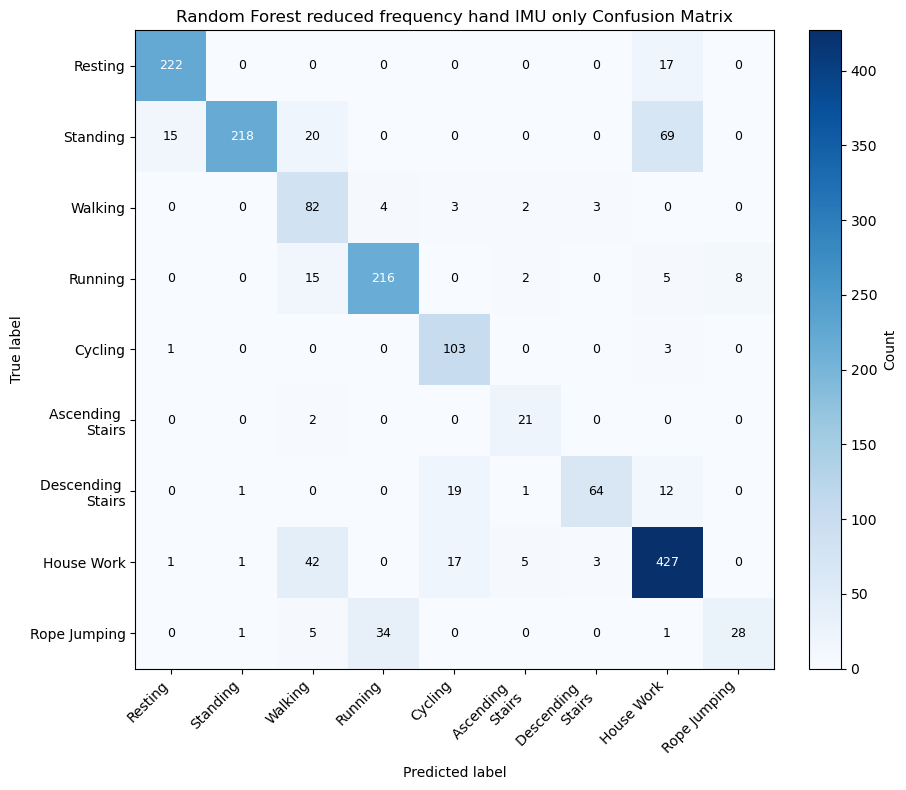

In [8]:
# Activity labels after class-combination:
# 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

# Use combined-category names in confusion matrix axes.
activity_name_map = {
    1: "Resting",
    3: "Standing",
    4: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    16: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope Jumping",
}

def _label_with_prefix(activity_id, prefix):
    name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
    return f"{name}"

cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels_sorted),
    index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
    columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
)

print("\nConfusion matrix (test set):")
print(cm)




# Pretty, colorized confusion matrix saved as PNG.
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm.values, cmap="Blues")

ax.set_xticks(np.arange(len(cm.columns)))
ax.set_yticks(np.arange(len(cm.index)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticklabels(cm.index)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Random Forest reduced frequency hand IMU only Confusion Matrix")

# Annotate each cell with count value.
threshold = cm.values.max() / 2 if cm.values.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm.iat[i, j]
        color = "white" if value > threshold else "black"
        ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
fig.tight_layout()

output_png = "random_forest_commerical_example_confusion_matrix.png"
fig.savefig(output_png, dpi=200, bbox_inches="tight")
print(f"\nSaved confusion matrix PNG: {output_png}")
plt.show()